# Calibrate-Orbitrap-NO3

A notebook to calibrate internal ESI-Orbitrap MS isotopologue delta values of samples, using the measured and true values of isotope standards analysed in a sequence.

Accepts either a single M0 sequence, or M0 and no-M0 sequences of the same samples.

Uses a Monte-Carlo approach (peturbation of input data by their uncertainties and c. 1000 repeat calculations) to estimate mean and error of each sample's true $\delta$- and $\Delta$-values. 

If M0+noM0 data: calculates $\delta$-values vs M0 peak using every possible basepeak, then a weighted average of certain basepeaks to give 'best estimate' $\delta$-values and errors.

From 'best estimate' $\delta$-values, derived $\Delta$-values and their errors for triple isotope and clumped isotope systems are calculated.

All errors are ±$1\sigma$

Calibrated data are reported in an excel file.

### Inputs:
- results_'YYYY-MM-DD'.xlsx file(s) containing internal isotopologue measurements of a sequence of samples and standards, eiher a single M0 or an M0 and a noM0 sequence for the same samples. Files must be in a subfolder named 'M0' or 'noM0'.
- references_nitrate.xlsx file, with referenced isotope values of the standards measured in the sequence.

### Output:
- 'current-dir'-calibrated-'YYYY-MM-DD'.xlsx, containing sheets for uncalibrated small $\delta$, calibrated small $\delta$, calculations of small $\delta$ vs M0 (if M0+no-M0 data), derived $\Delta$ values, a synthesis of the final $\delta$- and $\Delta$-values, and calibration metadata.

In [2]:
import os
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from datetime import datetime
current_datetime = datetime.now()
current_date_string = current_datetime.strftime("%Y-%m-%d")

/Users/jacksaville/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Find and import Orbitrap data, merge files, drop outlying rows
For automatic identification of files, they must be in appropriate 'M0' or 'noM0' subfolders, and be named 'results.....xlsx'

In [11]:
# FIND data files, decide if M0 or M0+noM0 data present by folder names
paths=[]
n_M0=0; n_noM0=0
# detect folders on path
folders = [folder for folder in os.listdir() if folder in ('m0','nom0','M0','noM0')]
for folder in folders:
    # select files within folder
    files = [file for file in sorted(os.listdir(folder)) if file.startswith('results') and file.endswith('.xlsx')]
    if len(files)==1:
        file = files[0]
        print('File',file,'found in folder',folder)
    elif len(files)>1.5:
        file = files[-1]
        print('File',file,'found in folder',folder,'(last file alphabetically selected from multiple files)')
    else:
        print('No file found in',folder)
    paths+=[os.path.join(folder,file)]
    # count instances of M0 or noM0 in folder names
    if folder.endswith(('nom0','noM0')):
        n_noM0+=1
    if folder.endswith(('m0','M0')):
        n_M0+=1
# automatically select data type
if n_noM0>0.5 and n_M0>0.5:
    data_type='M0+noM0'
    print('Data type =',data_type)
elif n_M0>0.5:
    data_type='M0-only'
    print('Data type =',data_type)
else:
    print('error selecting data type')
    
### Or manually input filename
# paths = ['250203_DC-2011-2_HSO4_noM0/results_2025-02-08.xlsx',
#          '250131_DC-2011-2_HSO4_M0/results_2025-02-08.xlsx']
### Or manually input data type
# data_type = 'M0-only'
# data_type = 'M0+noM0'


# IMPORT and MERGE data
data=pd.DataFrame()
data_merged = pd.DataFrame(columns=['sample_name'])

# load data from identified paths into a single dataframe
for path in paths:
    data = pd.concat([data, pd.read_excel(path,sheet_name='Bracketed deltas summary')],ignore_index=True)
    print('Data loaded',path)

# join data on sample name column, adding _basepeak as column suffix
for bp in data['basepeak'].unique():
    data_bp = data[data['basepeak']==bp].dropna(axis=1,how='all')
    data_bp.columns = ['sample_name']+[ col+'_'+bp for col in data_bp.columns if col not in 'sample_name']
    data_merged = pd.merge(data_merged,data_bp, on='sample_name',how='outer') 
     
# sort merged dataframe by sample name
data_merged = data_merged.sort_values('sample_name').set_index('sample_name',drop=True)

# IF NECESSARY rename samples to fit in alphabetical order and/or to match between data sets
if True:
    newnames=[]
    for name in data_merged.index:
    #     rename CDD-...
        if name.startswith('C'):
            num=name[1:]
            if '-' in num:
                num1=num.split('-')[0]
                if len(num1)==1:
                    num1='00'+num1
                if len(num1)==2:
                    num1='0'+num1
                num2=num.split('-')[1]
                if len(num2)==1:
                    num2='00'+num2
                if len(num2)==2:
                    num2='0'+num2
                num=num1+'-'+num2
            else:
                if len(num)==1:
                    num='00'+num
                if len(num)==2:
                    num='0'+num
            newname = 'CDD-'+num

        elif name.startswith('ech'):
            num=name[4:]
            if '-' in num:
                num1=num.split('-')[0]
                if len(num1)==1:
                    num1='00'+num1
                if len(num1)==2:
                    num1='0'+num1
                num2=num.split('-')[1]
                if len(num2)==1:
                    num2='00'+num2
                if len(num2)==2:
                    num2='0'+num2
                num=num1+'-'+num2
            else:
                if len(num)==1:
                    num='00'+num
                if len(num)==2:
                    num='0'+num
            newname = 'CDD-'+num
        else: 
            newname=name
        newnames+=[newname]
    data_merged.index=newnames

# sort rows alphabetically
data_merged = data_merged.loc[sorted(data_merged.index)]

### OPTIONAL INPUT: DROP any erroneous rows using this code
if False:
    to_drop = ['USGS34 non seche']
    data_merged = data_merged.loc[[row for row in data_merged.index if row not in to_drop]]
    print('Dropped rows:',to_drop)
### OPTIONAL INPUT, DROP any suprious values (replace with NaN)
if False:
    row = []
    col = []
    data_merged.loc[row,col]=np.nan
    print('Removed',row,'-',col)
    
# DISPLAY loaded, merged, cleaned data
data_merged[[col for col in data_merged.columns if col.startswith(('mean_','err_'))]]*1e3

File results_2025-01-21.xlsx found in folder M0
File results_2025-01-27.xlsx found in folder noM0
Data type = M0+noM0
Data loaded M0/results_2025-01-21.xlsx
Data loaded noM0/results_2025-01-27.xlsx


,mean_d15N_M0,mean_d17O_M0,mean_d18O_M0,err_d15N_M0,err_d17O_M0,err_d18O_M0,mean_d17O_15N,mean_d18O_15N,err_d17O_15N,err_d18O_15N,mean_d15N18O_15N,mean_d17O18O_15N,mean_d18O18O_15N,err_d15N18O_15N,err_d17O18O_15N,err_d18O18O_15N
CDD-282,-1.56,-1.16,3.46,0.46,0.86,0.35,0.82,3.59,0.39,0.27,4.65,4.18,6.82,1.47,3.88,1.98
CDD-285,0.29,5.01,7.40,0.55,0.91,0.43,4.23,7.20,0.37,0.28,8.88,17.26,14.74,1.57,4.06,2.94
CDD-286,-1.15,2.85,5.97,0.63,1.07,0.37,4.50,6.22,0.38,0.27,9.25,6.40,11.80,2.13,3.99,1.98
CDD-290,1.68,7.32,7.88,0.60,0.86,0.69,2.74,6.03,0.39,0.26,7.89,10.45,15.68,1.37,3.78,2.03
CDD-291,0.25,2.50,6.85,0.45,1.15,0.60,3.99,7.08,0.41,0.42,7.79,7.76,10.51,1.35,3.70,1.84
CDD-292,0.16,5.29,7.44,0.46,1.36,0.61,4.33,8.20,0.36,0.38,9.70,17.07,13.53,1.51,6.46,2.02
CDD-293,3.27,8.93,12.19,0.56,1.08,0.35,5.06,7.54,0.54,0.24,11.88,18.76,15.30,1.42,3.55,1.74
CDD-294,0.36,7.88,9.07,0.46,0.86,0.62,6.50,8.04,0.37,0.35,14.09,7.12,11.77,1.33,3.40,1.81
CDD-295,1.59,8.62,10.56,0.46,0.85,0.73,4.33,7.96,0.36,0.25,11.17,9.24,15.78,1.28,3.54,1.77
CDD-296,3.29,1.90,7.77,0.46,0.87,0.48,-1.12,2.98,0.36,0.30,4.62,0.17,9.61,1.68,4.42,1.60


### Recalculate average values for standards (from unaveraged sheet in excel file)
Each standard was prepared multiple repeat times. This block calculates means and standard error on standard delta values of *all* the injections of each standard

In [12]:
# dictionary for consistent renaming of standards
stds_dict = {'USGS32':'USGS32','USGS34':'USGS34','USGS35':'USGS35',
             'VS':'VolSol',
             'S1':'SMIF1','SMIF1':'SMIF1','S2':'SMIF2','SMIF2':'SMIF2',
             'Alpha':'Sulf-Alpha','alpha':'Sulf-Alpha','Beta':'Sulf-Beta','beta':'Sulf-Beta','Eps':'Sulf-Epsilon','eps':'Sulf-Epsilon','Epsilon':'Sulf-Epsilon','epsilon':'Sulf-Epsilon',
             'UW4':'SodSul4','U4':'SodSul4','SS4':'SodSul4','UWSS4':'SodSul4','UW8':'SodSul8','U8':'SodSul8','SS8':'SodSul8','UWSS8':'SodSul8'
            }

# load standard values from non-averaged excel sheet
data_std=pd.DataFrame()
data_std_merged = pd.DataFrame(columns=['sample_name'])

for path in paths:
    data_new = pd.read_excel(path,sheet_name='Bracketed deltas')
    data_new = data_new.loc[[row for row in data_new.index if (data_new.loc[row,'sample_name'].startswith(tuple(stds_dict.keys()))) & (data_new.loc[row,'sample_name'] in data_merged.index)]]
    for row in data_new.index:
        if data_new.loc[row,'sample_name'].endswith(('-1','-2','-3','-4','-5')):
            data_new.loc[row,'sample_name']=data_new.loc[row,'sample_name'][:-2]
    
    dcols=[col for col in data_new.columns if col.startswith('d') and not col.startswith(('dt','dT'))]
           
    data_new_means = data_new[['sample_name']+dcols].groupby('sample_name').mean()
    data_new_errs = data_new[['sample_name']+dcols].groupby('sample_name').sem()
    data_new_scans = data_new[['sample_name','scans_sample','scans_std']].groupby('sample_name').sum()
    
    data_new_means.columns = ['mean_'+col for col in data_new_means.columns]
    data_new_errs.columns = ['err_'+col for col in data_new_errs.columns]
    
    data_new_compiled = pd.concat([data_new_scans,data_new_means,data_new_errs], axis=1)
    data_new_compiled['basepeak']=data_new['basepeak'].iloc[0]
    data_new_compiled.reset_index(inplace=True)
    
    data_std = pd.concat([data_std, data_new_compiled])
    
# join data on sample name column, adding _basepeak as column suffix
for bp in data_std['basepeak'].unique():
    data_bp = data_std[data_std['basepeak']==bp].dropna(axis=1,how='all')
    data_bp.columns = ['sample_name']+[ col+'_'+bp for col in data_bp.columns if col not in 'sample_name']
    data_std_merged = pd.merge(data_std_merged,data_bp, on='sample_name',how='outer') 
    
data_std_merged.index=data_std_merged['sample_name']
data_std_merged = data_std_merged[[col for col in data_std_merged if not col=='sample_name']]

# renaming to match references data
index = data_std_merged.index.to_list()
newindex = [stds_dict[name] for name in index if name in stds_dict.keys()]
data_std_merged.index=newindex

# reinsert average std values into data_merged
data_merged = pd.concat([data_merged,data_std_merged],axis=0)

# display
data_merged[[col for col in data_merged.columns if col.startswith(('mean_','err_'))]]*1e3

,mean_d15N_M0,mean_d17O_M0,mean_d18O_M0,err_d15N_M0,err_d17O_M0,err_d18O_M0,mean_d17O_15N,mean_d18O_15N,err_d17O_15N,err_d18O_15N,mean_d15N18O_15N,mean_d17O18O_15N,mean_d18O18O_15N,err_d15N18O_15N,err_d17O18O_15N,err_d18O18O_15N
CDD-282,-1.56,-1.16,3.46,0.46,0.86,0.35,0.82,3.59,0.39,0.27,4.65,4.18,6.82,1.47,3.88,1.98
CDD-285,0.29,5.01,7.40,0.55,0.91,0.43,4.23,7.20,0.37,0.28,8.88,17.26,14.74,1.57,4.06,2.94
CDD-286,-1.15,2.85,5.97,0.63,1.07,0.37,4.50,6.22,0.38,0.27,9.25,6.40,11.80,2.13,3.99,1.98
CDD-290,1.68,7.32,7.88,0.60,0.86,0.69,2.74,6.03,0.39,0.26,7.89,10.45,15.68,1.37,3.78,2.03
CDD-291,0.25,2.50,6.85,0.45,1.15,0.60,3.99,7.08,0.41,0.42,7.79,7.76,10.51,1.35,3.70,1.84
CDD-292,0.16,5.29,7.44,0.46,1.36,0.61,4.33,8.20,0.36,0.38,9.70,17.07,13.53,1.51,6.46,2.02
CDD-293,3.27,8.93,12.19,0.56,1.08,0.35,5.06,7.54,0.54,0.24,11.88,18.76,15.30,1.42,3.55,1.74
CDD-294,0.36,7.88,9.07,0.46,0.86,0.62,6.50,8.04,0.37,0.35,14.09,7.12,11.77,1.33,3.40,1.81
CDD-295,1.59,8.62,10.56,0.46,0.85,0.73,4.33,7.96,0.36,0.25,11.17,9.24,15.78,1.28,3.54,1.77
CDD-296,3.29,1.90,7.77,0.46,0.87,0.48,-1.12,2.98,0.36,0.30,4.62,0.17,9.61,1.68,4.42,1.60


### Calculate and display pooled raw uncertainties (pre-calibration)
Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [13]:
# calculation pooled error for sample raw deltas
cols = [ col for col in data_merged.columns if col.startswith('err')]
rows = [ row  for row in data_merged.index if not row.startswith(tuple(stds_dict.keys()))]
errs = data_merged.loc[rows,cols]
pooled_err_precalib = (np.sum(errs**2,axis=0)/len(errs.index))**0.5
print('Pooled errors before calibration:\n\n',pooled_err_precalib*1e3)

Pooled errors before calibration:

 err_d15N_M0       0.53
err_d17O_M0       0.98
err_d18O_M0       0.53
err_d17O_15N      0.42
err_d18O_15N      0.32
err_d15N18O_15N   1.55
err_d17O18O_15N   4.39
err_d18O18O_15N   1.99
dtype: float64


### Inspect averaged internal $\delta$-value measurements of standards


In [14]:
standards = [std for std in data_merged.index if std in tuple(stds_dict.keys())]

# display mean, err
stds_stats = data_merged.loc[standards,
                       [col for col in data_merged.columns if col.startswith(('mean','err'))]]
stds_stats*1e3

,mean_d15N_M0,mean_d17O_M0,mean_d18O_M0,err_d15N_M0,err_d17O_M0,err_d18O_M0,mean_d17O_15N,mean_d18O_15N,err_d17O_15N,err_d18O_15N,mean_d15N18O_15N,mean_d17O18O_15N,mean_d18O18O_15N,err_d15N18O_15N,err_d17O18O_15N,err_d18O18O_15N
USGS32,158.90,-35.59,-30.52,0.61,0.55,0.33,-170.46,-164.33,0.36,0.18,-30.61,-193.20,-187.38,0.61,2.38,1.04
USGS34,-3.92,-59.88,-75.30,0.24,0.68,0.28,-57.09,-72.26,0.39,0.20,-76.66,-130.27,-141.92,1.14,2.22,1.02
USGS35,-0.43,0.09,0.00,0.32,0.70,0.18,-0.44,-0.35,0.26,0.18,0.52,0.58,-2.11,0.89,1.85,1.20


### Import reference data for the same standards

Note: for calibration of d15N where only USGS34 (d15N=-1.8) and USGS35 (d15N=2.7) measurements are available, only USGS35 was used for a one-point calibration, fixing the calibration slope empirically at b=1.1
This avoids large uncertainties on calibration slope originating from the small difference in d15N between the 2 standards. A third standard (e.g. USGS32, d15N=180) should be used to properly constrain the slope of the calibration.

In [15]:
ref_fn=[fn for fn in os.listdir() if fn.startswith('references_')][-1]
print('References file', ref_fn)

refs = pd.read_excel(ref_fn,index_col='sample_name')/1e3
refs = refs[refs.index.isin(stds_stats.index)].loc[standards]

# rename columns
cols=np.array(refs.columns)
for i,col in enumerate(cols):
    if '/' in col:
        col = col.replace('/','_')
    else:
        # col=col+'_M0'
        col=col
    cols[i]=col
refs.columns=cols

refs15N=refs.copy()
# remove USGS34 d15N value if only USGS35 and 34 present (see note above)
if len(refs15N)==2:
    if ('USGS34' in refs.index)&('USGS35' in refs.index):
        refs15N.loc['USGS34','d15N']=np.nan
        refs15N.loc['USGS34','err_d15N']=np.nan
        
refs*1e3

References file references_nitrate.xlsx


,d15N,D17O,d18O,D15N18O,D17O18O,D18O18O,err_d15N,err_D17O,err_d18O,err_D15N18O,err_D17O18O,err_D18O18O
sample_name,,,,,,,,,,,,
USGS32,180.00,NaN,25.70,0.00,0.00,0.00,0.00,0.20,0.40,0.00,0.00,0.00
USGS34,-1.80,-0.30,-27.90,0.00,0.00,0.00,0.20,0.20,0.60,0.00,0.00,0.00
USGS35,2.70,21.60,57.50,NaN,NaN,NaN,0.20,NaN,0.40,NaN,NaN,NaN


## Calibration calculation

Model:
#### $ y + 1 = (x + 1 )^b (a+1)$  
or
#### $ \log(y + 1 )= b \log(x+1)+ \log(a+1)$  
with  
#### $y=\delta_{true} ; x=\delta_{meas}$

Calculation: 

- if 1 (x,y) point: prescribe a gradient b and invert for intercept a
- if 2+ (x,y) points: linear regression of $log(y+1)$ against $log(x+1)
- if 3+ (x,y) points: can use the fit of the points to the regression line to quantify the quality of the linear calibration

Monte-Carlo approach: repeat calculation $nn$ times with inputs normally peturbed by their $1\sigma$ uncertainties. Best results with $nn>1000$.

For each repeat, store calculated slope (=b) and intercept (=log(1+a)) for each sample in a list, average the list and take its standard deviation at the end

Reference $\delta$ values which are unavailable (e.g. $\delta^{15}N^{18}O$) are calculated during the calibration, using measured $\delta$ values and reference $\Delta$ values

### Prepare DataFrames and functions for calibration

In [22]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# INPUT number of bootstraps - use nn > 1000 for best results (calculation time c. 5ms per iteration per isotopologue)
nn=1000

# Prep calibrated samples dataframe
# filter and order columns
mean_columns=[col for col in data_merged.columns if (col.startswith(('mean')))]
err_columns=[col for col in data_merged.columns if (col.startswith(('err')))]
samples = data_merged.loc[:,mean_columns+err_columns]

# define calibration function
def  calib_regression(x_data,y_data):
    x_vals=[]; y_vals=[];
    x_data_clean=pd.Series(x_data).dropna()
    y_data_clean=pd.Series(y_data).dropna()
    for standard in y_data_clean.index:
        # linear calibration of log(1+delta)
        x_vals.append(np.log(1 + x_data_clean.loc[standard]))
        y_vals.append(np.log(1 + y_data_clean.loc[standard]))
    x_vals = np.array(x_vals).reshape(-1,1)
    y_vals = np.array(y_vals).reshape(-1,1)
    
    if len(x_vals)>1.5:
        # linear regression
        reg = LinearRegression()
        reg.fit(x_vals, y_vals)
        slope=reg.coef_[0]
        intercept=reg.intercept_
    else:
        # 1-point calibration - INPUT PRESCRIBED SLOPE HERE for all isotopologues, or below if specific values for each isotopologue
        slope=np.array([1.1])
        intercept=np.array([y_vals[0]-x_vals[0]*slope])
    
    return [slope, intercept]

# results dataframes setup
columns = [col[5:] for col in samples.columns if (col[5:] in ['d15N_M0','d18O_M0','d17O_M0','D17O_M0','d17O_15N','d18O_15N','d15N18O_15N','d18O18O_15N'])]+['D17O_M0']
rows_sam = samples.index
rows_std = stds_stats.index
samples_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_sam))], columns=columns, index=rows_sam)
stds_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_std))], columns=columns, index=rows_std)

### M0 calibrations

15N; 18O; 17O (using d18O measurements and reference D17O to calculate reference d17O)


Mean intercept d15N: 2.85
Mean slope d15N: 1.10
Mean intercept d18O: 57.04
Mean slope d18O: 1.08
Mean intercept d17O: 49.93
Mean slope d17O: 1.06


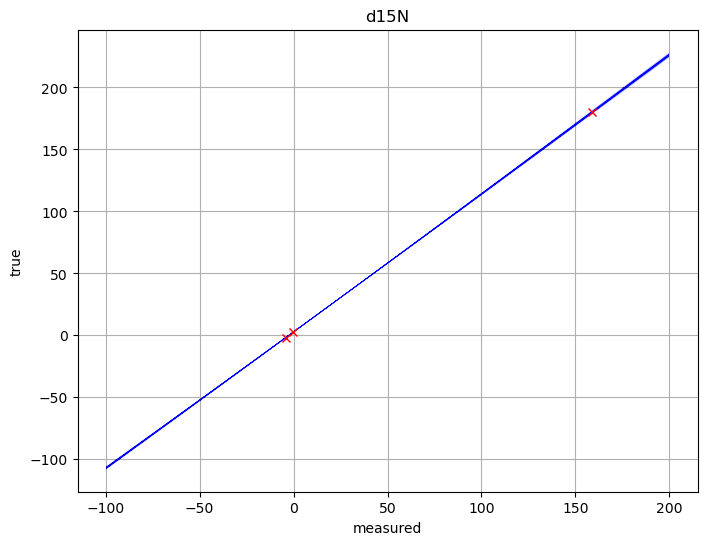

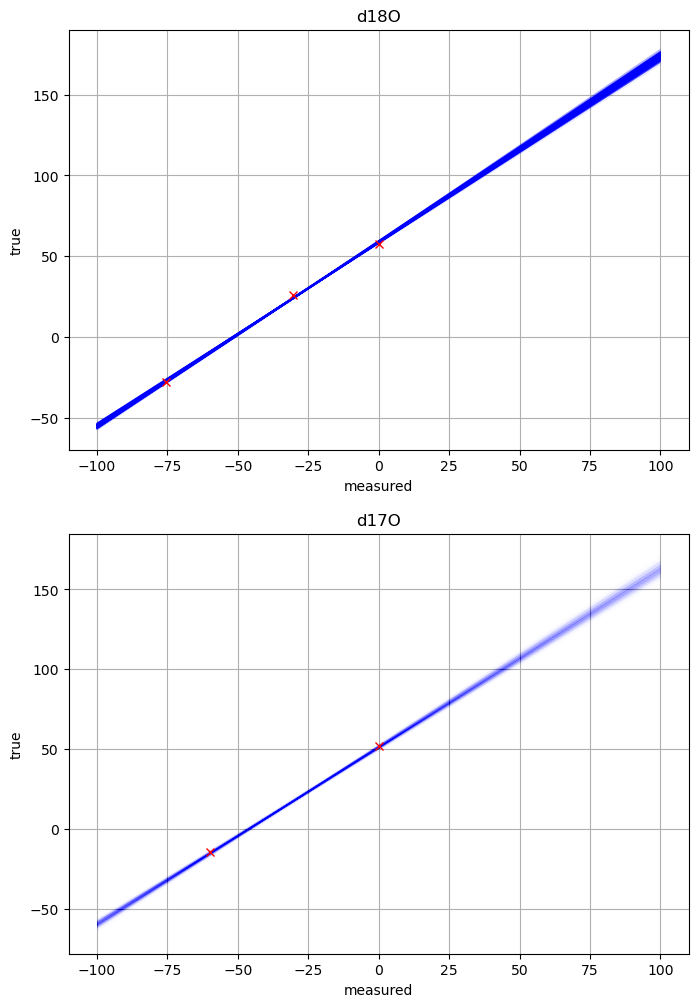

In [25]:
bp='M0'

### Nitrogen calibration
slope_15=[];intercept_15=[]

# plot for calib curves
fig,ax=plt.subplots(1,figsize=[8,6])
ax.grid()
ax.set_xlabel('measured')
ax.set_ylabel('true')
ax.set_title('d15N')

for n in range(nn):
    ## 15N  calibration:
    iso='15N'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs15N['d'+iso],refs15N['err_d'+iso])
    [slope, intercept] = calib_regression(x_data,y_data) 
    # OPTIONAL INPUT to force the slope or intercept for a specific isotopologue ratio, enter the values and their uncertainty and use these lines
    if False:
        slope[0]=np.random.normal(1,0)
        intercept[0]=np.random.normal(0,0)
    # store values in lists
    slope_15+=[slope[0]]
    intercept_15+=[intercept[0]]
    
    # add line to plot
    x=np.linspace(-100,200,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax.plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=10/nn)
    
    # CALIBRATE STDS and SAMPLES
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d15N_M0'] = np.random.normal(stds_stats['mean_d15N_M0'],stds_stats['err_d15N_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d15N_M0'] += [(stds_stats_pet.loc[row,'mean_d15N_M0']+1)**slope_15[-1] * np.exp(intercept_15[-1])-1]
    
    samples_pet=pd.DataFrame(index=samples.index)
    samples_pet['mean_d15N_M0'] = np.random.normal(samples['mean_d15N_M0'],samples['err_d15N_M0'])
    for row in samples_cal.index:
        samples_cal.loc[row,'d15N_M0'] += [(samples_pet.loc[row,'mean_d15N_M0']+1)**slope_15[-1] * np.exp(intercept_15[-1])-1]

        
ax.errorbar(stds_stats['mean_d15N_M0']*1e3,refs['d15N']*1e3,
                   c='r',linestyle='none',marker='x')  

print('Mean intercept d15N:', f"{np.mean(intercept_15)*1e3:.2f}")
print('Mean slope d15N:', f"{np.mean(slope_15):.2f}")



### Oxygen calibration

slope_17=[];slope_18=[];intercept_17=[];intercept_18=[]

# for calib curves
fig,ax=plt.subplots(2,figsize=[8,12])
for axis in ax:
    axis.grid()
    axis.set_xlabel('measured')
    axis.set_ylabel('true')
ax[0].set_title('d18O')
ax[1].set_title('d17O')

for n in range(nn):
    ## 18O  calibration:
    iso='18O'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs['d'+iso],refs['err_d'+iso])
    # call to regression func
    [slope, intercept] = calib_regression(x_data,y_data)  
    # store values in lists
    slope_18+=[slope[0]]
    intercept_18+=[intercept[0]]

    # calibrate standard 18O values - 
    d18_cal =  (stds_stats['mean_d'+iso+'_'+bp]+1)**slope * (intercept +1)-1
    
    # add line to plot
    x=np.linspace(-100,100,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax[0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)

    # 17O linear calibration based on known D17O values
    iso = '17O'   
    D_values = pd.Series(np.random.normal(refs['D17O'].dropna(), refs['err_D17O'].dropna()), index=refs['D17O'].dropna().index)
    #  calculate d17O values for standards, based on calibrated d18O measurement and known D17O.
    d_calc_stds = pd.Series(index=stds_stats.index).rename_axis('sample_name')
    for std in [std for std in stds_stats.index if std in D_values.index]:
        d_calc_stds.loc[std] = D_values.loc[std] + 0.52 * d18_cal.loc[std]
    if False:
        print('True',iso, 'calculated for standards, based on calibrated measurements and known D17O:\n',d_calc_stds*1e3)
    # regression
    x_data=np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    y_data=np.random.normal(d_calc_stds,0)
    [slope, intercept] = calib_regression(x_data,y_data)  
    # store values in lists 
    slope_17+=[slope[0]]
    intercept_17+=[intercept[0]]
    
    # add line to plot
    x=np.linspace(-100,100,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax[1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=10/nn)
    
    # CALIBRATE STDS and SAMPLES using model and the (a,b) obtained from regression; add delta values to lists to be averaged
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d18O_M0'] = np.random.normal(stds_stats['mean_d18O_M0'],stds_stats['err_d18O_M0'])
    stds_stats_pet['mean_d17O_M0'] = np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d18O_M0'] += [(stds_stats_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
        stds_cal.loc[row,'d17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
        stds_cal.loc[row,'D17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1 - 0.52*((stds_stats.loc[row,'mean_d18O_M0']+1)**slope_18[-1]* np.exp(intercept_18[-1])-1) ]
    
    samples_pet=pd.DataFrame(index=samples.index)
    samples_pet['mean_d18O_M0'] = np.random.normal(samples['mean_d18O_M0'],samples['err_d18O_M0'])
    samples_pet['mean_d17O_M0'] = np.random.normal(samples['mean_d17O_M0'],samples['err_d17O_M0'])
    for row in samples.index:
        samples_cal.loc[row,'d18O_M0'] += [(samples_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
        samples_cal.loc[row,'d17O_M0'] += [(samples_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
        samples_cal.loc[row,'D17O_M0'] += [(samples_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1 - 0.52*((samples_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1]* np.exp(intercept_18[-1])-1) ]
    
# add points for standards    
ax[0].errorbar(stds_stats['mean_d18O_M0']*1e3,refs['d18O']*1e3,
                   c='r',linestyle='none',marker='x')
# d17O points - calc
d17O_stds_calc = refs['D17O']+0.52*np.array([np.mean(stds_cal.loc[std,'d18O_M0']) for std in stds_cal.index])
ax[1].errorbar(stds_stats['mean_d17O_M0']*1e3,d17O_stds_calc*1e3,
                   c='r',linestyle='none',marker='x')    

mean_metadata_M0 = {'Intercept 15N':np.mean(intercept_15),
                    'Slope 15N':np.mean(slope_15),
                    'Intercept 18O':np.mean(intercept_18),
                    'Slope 18O':np.mean(slope_18),
                    'Intercept 17O':np.mean(intercept_17),
                    'Slope 17O':np.mean(slope_17)}

print('Mean intercept d18O:', f"{np.mean(intercept_18)*1e3:.2f}")
print('Mean slope d18O:', f"{np.mean(slope_18):.2f}")
print('Mean intercept d17O:', f"{np.mean(intercept_17)*1e3:.2f}")
print('Mean slope d17O:', f"{np.mean(slope_17):.2f}")

### no-M0 calibrations (if M0+noM0 data)
17O/15N; 18O/15N; 15N18O/15N; 18O18O/15N

Note: 1-point clumped isotopologue calibrations are likely to be inaccurate for samples far from the point - prefer 2 point calibrations (e.g. USGS34+USGS32)

Mean intercept d17O/15N: 47.97
Mean slope d17O/15N: 1.04
Mean intercept d18O/15N: 53.96
Mean slope d18O/15N: 1.08
Mean intercept d15N18O/15N: 59.81
Mean slope d15N8O/15N: 1.10
Mean intercept d18O18O/15N: 114.28
Mean slope d18O8O/15N: 1.10


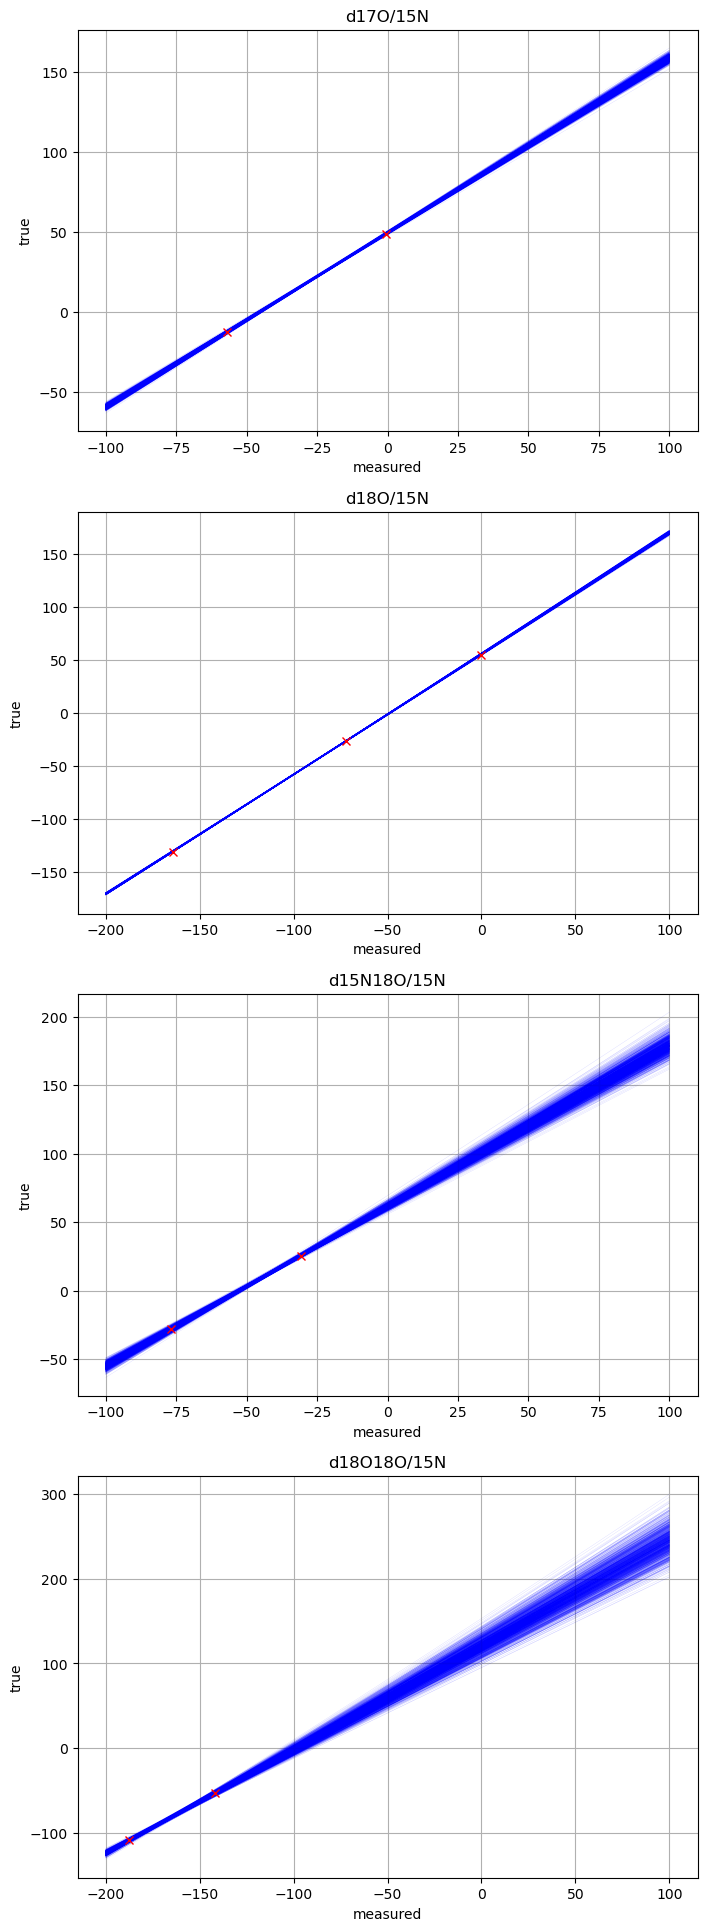

In [28]:
if data_type=='M0+noM0':

    # noM0 calibrations
    slope_17=[];slope_18=[];slope_1518=[];slope_1818=[]
    intercept_17=[];intercept_18=[];intercept_1518=[];intercept_1818=[]

    # for calib curves
    fig,ax=plt.subplots(4,figsize=[8,24])
    for axis in ax:
        axis.grid()
        axis.set_xlabel('measured')
        axis.set_ylabel('true')
    ax[0].set_title('d17O/15N')
    ax[1].set_title('d18O/15N')
    ax[2].set_title('d15N18O/15N')
    ax[3].set_title('d18O18O/15N')


    for n in range(nn):

        #     17O/15N
        d15 = pd.Series(np.random.normal(refs['d15N'].dropna(), refs['err_d15N'].dropna()), index=refs['d15N'].dropna().index)
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        D17 = pd.Series(np.random.normal(refs['D17O'].dropna(), refs['err_D17O'].dropna()), index=refs['D17O'].dropna().index)
        d_calc_stds = pd.Series(index=stds_stats.index).rename_axis('sample_name')

        for std in [std for std in stds_stats.index if std in D17.index]:
            d_calc_stds.loc[std] = ((1+(D17.loc[std]+0.52*d18.loc[std])) / (1+d15.loc[std]) -1)
        # regression
        x_data=np.random.normal(stds_stats['mean_d17O_15N'],stds_stats['err_d17O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_17+=[slope[0]]
        intercept_17+=[intercept[0]]

        # add line to plot
        x=np.linspace(-100,100,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)

        #     18O/15N
        d15 = pd.Series(np.random.normal(refs['d15N'].dropna(), refs['err_d15N'].dropna()), index=refs['d15N'].dropna().index)
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        d_calc_stds = pd.Series(index=stds_stats.index).rename_axis('sample_name')

        for std in [std for std in stds_stats.index if std in d18.index]:
            d_calc_stds.loc[std] = ((1+d18.loc[std]) / (1+d15.loc[std]) -1)
        # regression
        x_data=np.random.normal(stds_stats['mean_d18O_15N'],stds_stats['err_d18O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_18+=[slope[0]]
        intercept_18+=[intercept[0]]

        # add line to plot
        x=np.linspace(-200,100,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)

        # 15N18O/15N
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        d_calc_stds = d18.loc[[row for row in d18.index if row !='USGS35']]

        # regression
        x_data=np.random.normal(stds_stats['mean_d15N18O_15N'],stds_stats['err_d15N18O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_1518+=[slope[0]]
        intercept_1518+=[intercept[0]]

        # add line to plot
        x=np.linspace(-100,100,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[2].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)

           # 18O18O/15N
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        d15 = pd.Series(np.random.normal(refs['d15N'].dropna(), refs['err_d15N'].dropna()), index=refs['d15N'].dropna().index)
        d_calc_stds = (1+d18.loc[[row for row in d18.index if row !='USGS35']])**2/(1+d15.loc[[row for row in d18.index if row !='USGS35']])-1
        # regression
        x_data=np.random.normal(stds_stats['mean_d18O18O_15N'],stds_stats['err_d18O18O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_1818+=[slope[0]]
        intercept_1818+=[intercept[0]]

        # add line to plot
        x=np.linspace(-200,100,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[3].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)


        # CALIBRATE STDS and SAMPLES using model and the (a,b) obtained from regression; add delta values to lists to be averaged
        stds_stats_pet=pd.DataFrame(index=stds_stats.index)
        stds_stats_pet['mean_d17O_15N'] = np.random.normal(stds_stats['mean_d17O_15N'],stds_stats['err_d17O_15N'])
        stds_stats_pet['mean_d18O_15N'] = np.random.normal(stds_stats['mean_d18O_15N'],stds_stats['err_d18O_15N'])
        stds_stats_pet['mean_d15N18O_15N'] = np.random.normal(stds_stats['mean_d15N18O_15N'],stds_stats['err_d15N18O_15N'])
        stds_stats_pet['mean_d18O18O_15N'] = np.random.normal(stds_stats['mean_d18O18O_15N'],stds_stats['err_d18O18O_15N'])

        for row in stds_cal.index:
            stds_cal.loc[row,'d17O_15N'] += [(stds_stats_pet.loc[row,'mean_d17O_15N']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
            stds_cal.loc[row,'d18O_15N'] += [(stds_stats_pet.loc[row,'mean_d18O_15N']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
            stds_cal.loc[row,'d15N18O_15N'] += [(stds_stats_pet.loc[row,'mean_d15N18O_15N']+1)**slope_1518[-1] * np.exp(intercept_1518[-1])-1]
            stds_cal.loc[row,'d18O18O_15N'] += [(stds_stats_pet.loc[row,'mean_d18O18O_15N']+1)**slope_1818[-1] * np.exp(intercept_1818[-1])-1]

        samples_pet=pd.DataFrame(index=samples.index)
        samples_pet['mean_d17O_15N'] = np.random.normal(samples['mean_d17O_15N'],samples['err_d17O_15N'])
        samples_pet['mean_d18O_15N'] = np.random.normal(samples['mean_d18O_15N'],samples['err_d18O_15N'])
        samples_pet['mean_d15N18O_15N'] = np.random.normal(samples['mean_d15N18O_15N'],samples['err_d15N18O_15N'])
        samples_pet['mean_d18O18O_15N'] = np.random.normal(samples['mean_d18O18O_15N'],samples['err_d18O18O_15N'])
        for row in samples.index:
            samples_cal.loc[row,'d17O_15N'] += [(samples_pet.loc[row,'mean_d17O_15N']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
            samples_cal.loc[row,'d18O_15N'] += [(samples_pet.loc[row,'mean_d18O_15N']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
            samples_cal.loc[row,'d15N18O_15N'] += [(samples_pet.loc[row,'mean_d15N18O_15N']+1)**slope_1518[-1] * np.exp(intercept_1518[-1])-1]
            samples_cal.loc[row,'d18O18O_15N'] += [(samples_pet.loc[row,'mean_d18O18O_15N']+1)**slope_1818[-1] * np.exp(intercept_1818[-1])-1]

    # 17/15 points on curves - calc
    d1715_stds_calc = ( 1 + refs['D17O']+0.52*refs['d18O'] ) / (1+refs['d15N']) -1
    ax[0].errorbar(stds_stats['mean_d17O_15N']*1e3,d1715_stds_calc*1e3,
                       c='r',linestyle='none',marker='x')    
    # 18/15 points on curves - calc
    d1815_stds_calc = ( 1 + refs['d18O'] ) / (1+refs['d15N']) -1
    ax[1].errorbar(stds_stats['mean_d18O_15N']*1e3,d1815_stds_calc*1e3,
                       c='r',linestyle='none',marker='x') 

    # 1518/15 points on curves
    stds_names = [std for std in ['USGS32','USGS34'] if std in refs.index]
    d151815_stds_calc = refs.loc[stds_names,'d18O']
    ax[2].errorbar(stds_stats.loc[stds_names,'mean_d15N18O_15N']*1e3,d151815_stds_calc*1e3,
                       c='r',linestyle='none',marker='x') 

    # 1818/15 points on curves
    stds_names = [std for std in ['USGS32','USGS34'] if std in refs.index]
    d181815_stds_calc = (1+refs.loc[stds_names,'d18O'])**2/(1+refs.loc[stds_names,'d15N'])-1
    ax[3].errorbar(stds_stats.loc[stds_names,'mean_d18O18O_15N']*1e3,d181815_stds_calc*1e3,
                       c='r',linestyle='none',marker='x') 

    mean_metadata_noM0 = {'Intercept 18O/15N':np.mean(intercept_18),
                        'Slope 18O/15N':np.mean(slope_18),
                        'Intercept 17O/15N':np.mean(intercept_17),
                        'Slope 17O/15N':np.mean(slope_17),
                          'Intercept 15N18O/15N':np.mean(intercept_1518),
                        'Slope 15N18O/15N':np.mean(slope_1518),
                        'Intercept 18O18O/15N':np.mean(intercept_1818),
                        'Slope 18O18O/15N':np.mean(slope_1818)}

    print('Mean intercept d17O/15N:', f"{np.mean(intercept_17)*1e3:.2f}")
    print('Mean slope d17O/15N:', f"{np.mean(slope_17):.2f}")
    print('Mean intercept d18O/15N:', f"{np.mean(intercept_18)*1e3:.2f}")
    print('Mean slope d18O/15N:', f"{np.mean(slope_18):.2f}")
    print('Mean intercept d15N18O/15N:', f"{np.mean(intercept_1518)*1e3:.2f}")
    print('Mean slope d15N8O/15N:', f"{np.mean(slope_1518):.2f}")
    print('Mean intercept d18O18O/15N:', f"{np.mean(intercept_1818)*1e3:.2f}")
    print('Mean slope d18O8O/15N:', f"{np.mean(slope_1818):.2f}")
    
else:
    print('Block skipped because no no-M0 data loaded')

## Averaging the $nn$ $\delta$-values for each isotopologue ratio
Calculates mean and standard deviation (alternatively median and IQR) of $nn$ values for each isotopologue ratio for each sample or standard

In [29]:
def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final =averaging(samples_cal)
stds_cal_final = averaging(stds_cal)

samples_cal_final*1e3

,d15N_M0,d17O_M0,d18O_M0,d17O_15N,d18O_15N,d15N18O_15N,d18O18O_15N,D17O_M0,d15N_M0_err,d17O_M0_err,d18O_M0_err,d17O_15N_err,d18O_15N_err,d15N18O_15N_err,d18O18O_15N_err,D17O_M0_err
CDD-282,1.13,49.90,62.64,50.04,59.49,66.97,129.25,17.33,0.56,1.27,0.59,0.64,0.58,2.54,9.82,1.26
CDD-285,3.17,56.74,67.17,53.76,63.62,71.94,139.00,21.82,0.65,1.36,0.70,0.65,0.61,2.74,10.70,1.36
CDD-286,1.58,54.37,65.52,54.06,62.50,72.35,135.40,20.29,0.75,1.49,0.63,0.66,0.59,3.24,10.09,1.49
CDD-290,4.71,59.29,67.69,52.14,62.29,70.78,140.14,24.09,0.69,1.35,0.93,0.64,0.58,2.50,10.30,1.39
CDD-291,3.11,53.96,66.49,53.50,63.50,70.65,133.79,19.38,0.56,1.54,0.82,0.68,0.71,2.52,9.94,1.57
CDD-292,3.02,57.07,67.18,53.87,64.75,72.97,137.51,22.14,0.58,1.80,0.87,0.64,0.67,2.72,10.22,1.81
CDD-293,6.46,61.10,72.65,54.64,64.02,75.48,139.76,23.32,0.69,1.53,0.66,0.77,0.58,2.72,10.18,1.53
CDD-294,3.25,59.96,69.07,56.23,64.58,78.08,135.33,24.05,0.57,1.35,0.87,0.67,0.66,2.70,10.08,1.38
CDD-295,4.64,60.74,70.76,53.88,64.48,74.61,140.38,23.94,0.56,1.35,0.99,0.63,0.59,2.57,10.28,1.39
CDD-296,6.48,53.31,67.56,47.93,58.80,67.01,132.71,18.18,0.58,1.32,0.73,0.60,0.60,2.72,9.87,1.32


### Calculate and display pooled uncertainties pre-and post-calibration

Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [30]:
# calculation pooled error after calib
cols = [ col for col in samples_cal_final.columns if col.endswith('err')]
rows = [ row  for row in samples_cal_final.index if not row.startswith(tuple(stds_dict))]
errs = samples_cal_final.loc[rows,cols]
# Compute post-calibration pooled error
pooled_err_postcalib = pd.DataFrame(
    (np.sum(errs**2, axis=0) / len(errs.index))**0.5,
    columns=['Pooled error post-calibration'])
# Clean up indices
pooled_err_postcalib.index = [s[:-4] for s in pooled_err_postcalib.index]
pooled_err_precalib2 = pooled_err_precalib.copy()
pooled_err_precalib2 = pd.DataFrame(
    pooled_err_precalib2,
    columns=['Pooled error pre-calibration'])
pooled_err_precalib2.index = [s[4:] for s in pooled_err_precalib2.index]

# Merge the two df
pooled_errs = pd.DataFrame()
pooled_errs['Pooled error pre-calibration']=pooled_err_precalib2['Pooled error pre-calibration']
pooled_errs['Pooled error post-calibration']=pooled_err_postcalib['Pooled error post-calibration']

# display 
print('Pooled errors:')
pooled_errs * 1e3

Pooled errors:


,Pooled error pre-calibration,Pooled error post-calibration
d15N_M0,0.53,0.64
d17O_M0,0.98,1.43
d18O_M0,0.53,0.78
d17O_15N,0.42,0.68
d18O_15N,0.32,0.63
d15N18O_15N,1.55,2.72
d17O18O_15N,4.39,NaN
d18O18O_15N,1.99,10.16


### Calculations of 'best estimate' $\delta$-values w.r.t. M0 (only if M0+noM0)

Translation of noM0 $\delta$-values to M0 $\delta$-values

Calculation:
#### $\delta(\frac{X}{M_0})+1 = \frac{\delta(\frac{X}{B})+1}{\delta(\frac{B}{M_0})+1}$
For any substituted isotopologue $X$ and any basepeak $B$ measured in both M0 and no-M0 experiments

1. The calculation is made for each possible basepeak ($B=$ 15N, 17O, 18O) for every substituted isotopologue $X$, for every sample/standard, uncertainties are propagated analytically
2. An average $\delta$-value is calculated for every substituted isotopologue, using the basepeaks chosen in 'averaging_dict'. Average is weighted by uncertainty (weights = $1/\sigma^2$)

The dataframe 'small_deltas' contains every calculation, its error, the weighted average and its error for each substituted isotopologue, for each sample/standard

In [31]:
# define weighted averaging function
def averaging(vals,errs):
    weights = 1/errs**2 
    # Calculate weighted average
    average = np.average(vals, weights=weights, axis=0)
    # Calculate sum of weights
    sum_weights = np.sum(weights, axis=0)
    # Calculate uncertainty of the average
    errors = (1 / sum_weights) * ( np.sum((errs*weights)**2,axis=0) )**0.5

    return [average,errors]  

if data_type == 'M0+noM0':

    data = samples_cal_final.copy()

    calc_deltas = pd.DataFrame()
    calc_deltas['d15N_M0']=data['d15N_M0']
    calc_deltas['d15N_M0_err']=data['d15N_M0_err']
    calc_deltas['d15N_noM0-18O']=(data['d18O_M0']+1)/(data['d18O_15N']+1)-1
    calc_deltas['d15N_noM0-18O_err']=(data['d18O_15N_err']**2+data['d18O_M0_err']**2)**0.5
    calc_deltas['d15N_noM0-17O']=(data['d17O_M0']+1)/(data['d17O_15N']+1)-1
    calc_deltas['d15N_noM0-17O_err']=( data['d17O_M0_err']**2
                                 +data['d17O_15N_err']**2)**0.5

    calc_deltas['d18O_M0']=data['d18O_M0']
    calc_deltas['d18O_M0_err']=data['d18O_M0_err']
    calc_deltas['d18O_noM0-15N']=(data['d18O_15N']+1)*(data['d15N_M0']+1)-1
    calc_deltas['d18O_noM0-15N_err']=(data['d18O_15N_err']**2+data['d15N_M0_err']**2)**0.5
    calc_deltas['d18O_noM0-17O']=(data['d18O_15N']+1)*(data['d17O_M0']+1)/(data['d17O_15N']+1)-1
    calc_deltas['d18O_noM0-17O_err']=( data['d17O_15N_err']**2*(1-1.14e-3/5.14e-3)
                                 +data['d18O_15N_err']**2*(1-6e-3/10e-3)
                                 +data['d17O_M0_err']**2)**0.5

    calc_deltas['d17O_M0']=data['d17O_M0']
    calc_deltas['d17O_M0_err']=data['d17O_M0_err']
    calc_deltas['d17O_noM0-15N']=(data['d17O_15N']+1)*(data['d15N_M0']+1)-1
    calc_deltas['d17O_noM0-15N_err']=(data['d17O_15N_err']**2+data['d15N_M0_err']**2)**0.5
    calc_deltas['d17O_noM0-18O']=(data['d17O_15N']+1)*(data['d18O_M0']+1)/(data['d18O_15N']+1)-1
    calc_deltas['d17O_noM0-18O_err']=( data['d17O_15N_err']**2*(1-1.14e-3/5.14e-3)
                                 +data['d18O_15N_err']**2*(1-6e-3/10e-3)
                                 +data['d18O_M0_err']**2)**0.5

    calc_deltas['d15N18O_noM0-15N']=(data['d15N18O_15N']+1)*(data['d15N_M0']+1)-1
    calc_deltas['d15N18O_noM0-15N_err']=(data['d15N18O_15N_err']**2+data['d15N_M0_err']**2)**0.5
    calc_deltas['d15N18O_noM0-18O']=(data['d15N18O_15N']+1)*(data['d18O_M0']+1)/(data['d18O_15N']+1)-1
    calc_deltas['d15N18O_noM0-18O_err']=( data['d15N18O_15N_err']**2
                                 +data['d18O_15N_err']**2*(1-6e-3/10e-3)
                                 +data['d18O_M0_err']**2)**0.5
    calc_deltas['d15N18O_noM0-17O']=(data['d15N18O_15N']+1)*(data['d17O_M0']+1)/(data['d17O_15N']+1)-1
    calc_deltas['d15N18O_noM0-17O_err']=( data['d15N18O_15N_err']**2
                                 +data['d17O_15N_err']**2*(1-1.14e-3/5.14e-3)
                                 +data['d17O_M0_err']**2)**0.5

    calc_deltas['d18O18O_noM0-15N']=(data['d18O18O_15N']+1)*(data['d15N_M0']+1)-1
    calc_deltas['d18O18O_noM0-15N_err']=(data['d18O18O_15N_err']**2+data['d15N_M0_err']**2)**0.5
    calc_deltas['d18O18O_noM0-18O']=(data['d18O18O_15N']+1)*(data['d18O_M0']+1)/(data['d18O_15N']+1)-1
    calc_deltas['d18O18O_noM0-18O_err']=( data['d18O18O_15N_err']**2
                                 +data['d18O_15N_err']**2*(1-6e-3/10e-3)
                                 +data['d18O_M0_err']**2)**0.5
    calc_deltas['d18O18O_noM0-17O']=(data['d18O18O_15N']+1)*(data['d17O_M0']+1)/(data['d17O_15N']+1)-1
    calc_deltas['d18O18O_noM0-17O_err']=( data['d18O18O_15N_err']**2
                                 +data['d17O_15N_err']**2*(1-1.14e-3/5.14e-3)
                                 +data['d17O_M0_err']**2)**0.5

    # calc_deltas['d17O18O_noM0-15N']=(data['mean_d17O18O_15N']+1)*(data['mean_d15N_M0']+1)-1
    # calc_deltas['d17O18O_noM0-15N_err']=np.sqrt(data['err_d17O18O_15N']**2+data['err_d15N_M0']**2)
    # calc_deltas['d17O18O_noM0-18O']=(data['mean_d17O18O_15N']+1)*(data['mean_d18O_M0']+1)/(data['mean_d18O_15N']+1)-1
    # calc_deltas['d17O18O_noM0-18O_err']=np.sqrt( data['err_d17O18O_15N']**2
    #                              +data['err_d18O_15N']**2*(1-6e-3/10e-3)
                                 # +data['err_d18O_M0']**2)
    # calc_deltas['d17O18O_noM0-17O']=(data['mean_d17O18O_15N']+1)*(data['mean_d17O_M0']+1)/(data['mean_d17O_15N']+1)-1
    # calc_deltas['d17O18O_noM0-17O_err']=np.sqrt( data['err_d17O18O_15N']**2
    #                              +data['err_d17O_15N']**2*(1-1.14e-3/5.14e-3)
    #                              +data['err_d17O_M0']**2)


    # calculate weighted average of each delta. Store in columns _average/_average_err
    # combine into a single dataframe

    # INPUT the basepeak calculations to include in the weighted average
    averaging_dict = {'d15N_average-M0+18O':['d15N_M0','d15N_noM0-18O'],
                      'd15N_M0':['d15N_M0'],
                      # 'd15N_average-all':['d15N_M0','d15N_noM0-18O','d15N_noM0-17O'],
                     'd17O_average-noM0':['d17O_noM0-15N','d17O_noM0-18O'],
                      'd17O_M0':['d17O_M0'],
                     # 'd17O_average-all':['d17O_M0','d17O_noM0-15N','d17O_noM0-18O'],
                     'd18O_average-M0+15N':['d18O_M0','d18O_noM0-15N'],
                      'd18O_M0':['d18O_M0'],
                     # 'd18O_average-all':['d18O_M0','d18O_noM0-15N','d18O_noM0-17O'],
                     'd15N18O_average-15N+18O':['d15N18O_noM0-15N','d15N18O_noM0-18O'],
                      # 'd15N18O_average-all':['d15N18O_noM0-15N','d15N18O_noM0-18O','d15N18O_noM0-17O'],
                      'd18O18O_average-15N+18O':['d18O18O_noM0-15N','d18O18O_noM0-18O'],
                      # 'd15N18O_average-all':['d15N18O_noM0-15N','d15N18O_noM0-18O','d15N18O_noM0-17O']
                     }
    small_deltas=pd.DataFrame()
    for delta in averaging_dict.keys():

        cols = [col for col in calc_deltas.columns if col.startswith(tuple(averaging_dict[delta]))]
        print ('Calculation of',delta,' using ',cols)
        data_d = calc_deltas.loc[:,cols]
        av,err = averaging(np.array([data_d[col] for col in data_d.columns if not col.endswith('err')]),np.array([data_d[col] for col in data_d.columns if col.endswith('err')]))
        data_d[delta]=av
        data_d[delta+'_err']=err
        small_deltas[data_d.columns]=data_d

    small_deltas = small_deltas = small_deltas[sorted(small_deltas.columns)]
    small_deltas*1e3
    
else:
    print('Block skipped because no no-M0 data')

Calculation of d15N_average-M0+18O  using  ['d15N_M0', 'd15N_M0_err', 'd15N_noM0-18O', 'd15N_noM0-18O_err']
Calculation of d15N_M0  using  ['d15N_M0', 'd15N_M0_err']
Calculation of d17O_average-noM0  using  ['d17O_noM0-15N', 'd17O_noM0-15N_err', 'd17O_noM0-18O', 'd17O_noM0-18O_err']
Calculation of d17O_M0  using  ['d17O_M0', 'd17O_M0_err']
Calculation of d18O_average-M0+15N  using  ['d18O_M0', 'd18O_M0_err', 'd18O_noM0-15N', 'd18O_noM0-15N_err']
Calculation of d18O_M0  using  ['d18O_M0', 'd18O_M0_err']
Calculation of d15N18O_average-15N+18O  using  ['d15N18O_noM0-15N', 'd15N18O_noM0-15N_err', 'd15N18O_noM0-18O', 'd15N18O_noM0-18O_err']
Calculation of d18O18O_average-15N+18O  using  ['d18O18O_noM0-15N', 'd18O18O_noM0-15N_err', 'd18O18O_noM0-18O', 'd18O18O_noM0-18O_err']


### Plots of $\delta(X/M_0)$ for each basepeak $B$ (for M0+no-M0 data only)
Check that the basepeak calculations do not disagree with each other much beyond their error bars. If so, this is a sign that one of the measurements or calibrations may be bad.

/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76885/1935222530.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


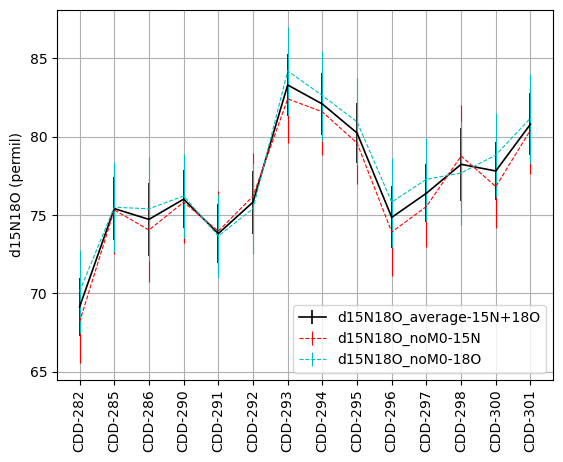

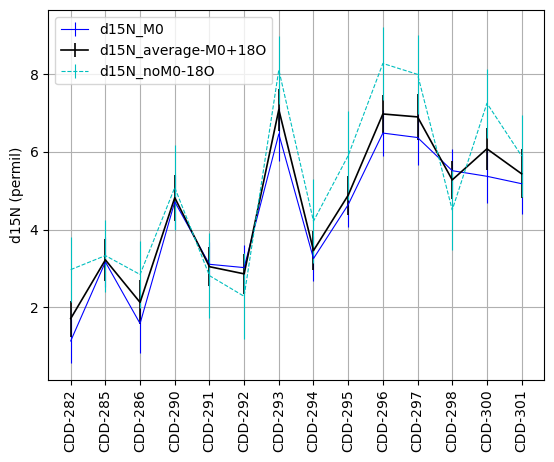

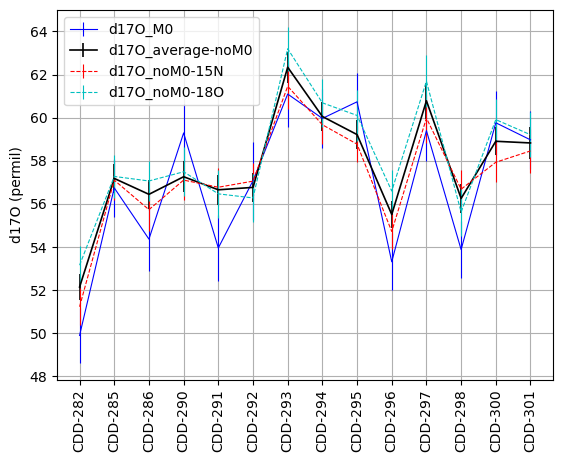

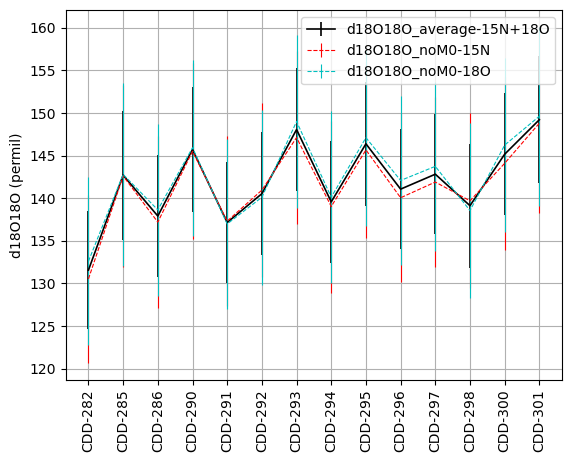

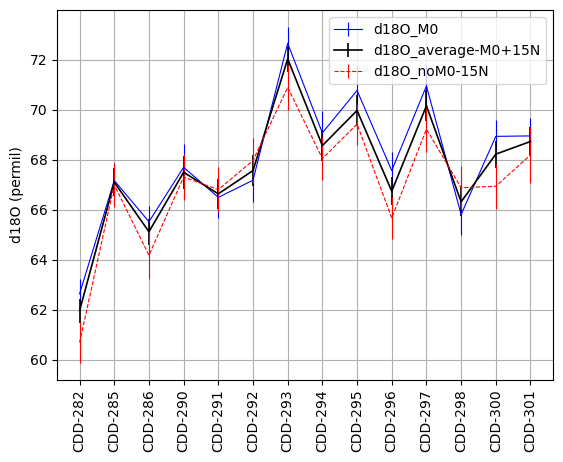

In [39]:
if data_type=='M0+noM0':

    # True = plots only samples, False = plots standards also
    if True:
        data_plot = small_deltas.loc[[row for row in small_deltas.index if not row.startswith(tuple(stds_dict))]]
    else:
        data_plot = small_deltas 
        
    # plots for each little delta
    for delta in pd.Series([col.split('_')[0] for col in data_plot.columns]).unique():
        fig,ax=plt.subplots()
        cols = [col for col in data_plot.columns if col.startswith(delta+'_') and not col.endswith('_err')]
        for col in cols:
            if col.split('_')[1].startswith('average'):
                ls='-';lw=1.2;c='k'
            elif col.split('_')[1]=='M0':
                ls='-';lw=0.8;c='b'
            elif col.split('-')[-1]=='15N':
                ls='--';lw=0.8;c='r'
            elif col.split('-')[-1]=='18O':
                ls='--';lw=0.8;c='c'
            elif col.split('-')[-1]=='17O':
                ls='--';lw=0.8;c='m'
            ax.errorbar(x=data_plot.index,y=data_plot[col]*1e3,yerr=data_plot[col+'_err']*1e3,ls=ls,lw=lw,c=c,label=col)

        ax.set_ylabel(delta+' (permil)')
        ax.legend()
        ax.grid()
        ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
        
else:
    print('Block skipped because no no-M0 data')

## Calculation of derived $\Delta$-values (if M0+no-M0 data)

From 'best estimate' $\delta$-values

In [51]:
if data_type=='M0-only':
    derived_deltas = pd.DataFrame()
    print('Block skipped because no no-M0 data')

else:
    # capital Deltas, value and propograted error

    def calc_D17O(d17data,d17err, d18data,d18err):
        val = d17data - 0.52*d18data
        err = (d17err**2+(0.52*d18err)**2)**0.5
        return pd.DataFrame({'D17O':val,'D17O_err':err})

    def calc_D15N18O(d1518data,d1518err, d15data,d15err, d18data,d18err):
        val = (1+d1518data)/((1+d15data)*(1+d18data)) -1
        err = (d1518err**2+d15err**2+d18err**2)**0.5
        return pd.DataFrame({'D15N18O':val,'D15N18O_err':err})

    def calc_D18O18O(d1818data,d1818err, d18data,d18err):
        val = (1+d1818data)/((1+d18data)*(1+d18data)) -1
        err = (d1818err**2+(2*d18err)**2)**0.5
        return pd.DataFrame({'D18O18O':val,'D18O18O_err':err})

    derived_deltas=pd.DataFrame()


    derived_deltas[['D17O','D17O_err']] = calc_D17O(small_deltas['d17O_average-noM0'],small_deltas['d17O_average-noM0_err'],
                                                        small_deltas['d18O_average-M0+15N'],small_deltas['d18O_average-M0+15N_err'])
    # M0-only D17O
    derived_deltas[['D17O_M0','D17O_M0_err']] = calc_D17O(small_deltas['d17O_M0'],small_deltas['d17O_M0_err'],
                                                    small_deltas['d18O_M0'],small_deltas['d18O_M0_err'])

    derived_deltas[['D15N18O','D15N18O_err']] = calc_D15N18O(small_deltas['d15N18O_average-15N+18O'],small_deltas['d15N18O_average-15N+18O_err'],
                                                             small_deltas['d15N_average-M0+18O'],small_deltas['d15N_average-M0+18O_err'],
                                                             small_deltas['d18O_average-M0+15N'],small_deltas['d18O_average-M0+15N_err'])

    derived_deltas[['D18O18O','D18O18O_err']] = calc_D18O18O(small_deltas['d18O18O_average-15N+18O'],small_deltas['d18O18O_average-15N+18O_err'],
                                                             small_deltas['d18O_average-M0+15N'],small_deltas['d18O_average-M0+15N_err'])

# display
derived_deltas*1e3

,D17O,D17O_err,D17O_M0,D17O_M0_err,D15N18O,D15N18O_err,D18O18O,D18O18O_err
CDD-282,19.92,0.66,17.33,1.30,5.04,1.96,3.37,7.02
CDD-285,22.29,0.73,21.82,1.41,4.56,2.15,3.52,7.66
CDD-286,22.58,0.74,20.29,1.53,6.88,2.47,3.02,7.23
CDD-290,22.16,0.80,24.09,1.43,3.15,2.06,5.42,7.42
CDD-291,22.00,0.76,19.38,1.59,3.68,2.02,-0.49,7.16
CDD-292,21.63,0.76,22.14,1.86,4.87,2.16,0.74,7.36
CDD-293,24.89,0.78,23.32,1.57,3.41,2.13,-1.02,7.29
CDD-294,24.40,0.76,24.05,1.42,9.17,2.14,-1.97,7.25
CDD-295,22.83,0.76,23.94,1.44,4.70,2.08,1.37,7.40
CDD-296,20.81,0.70,18.18,1.37,0.63,2.12,2.76,7.08


## Compilation into single DataFrame, pooled final uncertainties
Reports values for:

- (d15N, D17O, d18O) if M0-only

- Averaged (d15N, D17O, d18O, D15N18O, D18O18O) if M0+noM0

In [52]:
if data_type=='M0+noM0':
# compile averaged small deltas and derived deltas into a single dataframe
    data_summary = pd.DataFrame()

    # select which small deltas to report in summary dataframe
    small_deltas_to_report = ['d15N','d15N_err','d18O','d18O_err']
    small_d_cols = [col for col in small_deltas.columns if (col.split('_')[1].startswith('average')) & (col.startswith(tuple(( d+'_' for d in small_deltas_to_report))))]
    derived_D_cols = [col for col in derived_deltas.columns.tolist() if not col.startswith('D17O_M0')]

    # join in single DataFrame
    data_summary[small_deltas_to_report]=small_deltas[small_d_cols]
    data_summary[derived_D_cols]=derived_deltas[derived_D_cols]

else:
    data_summary = samples_cal_final[[col for col in samples_cal_final if col.startswith(('d15','D17','d18'))]]
    
# calculation pooled error for raw deltas
cols = [ col for col in data_summary.columns if col.endswith('err')]
rows = [ row  for row in data_summary.index if not row.startswith(tuple(stds_dict.keys()))]
errs = data_summary.loc[rows,cols]
pooled_err_final = (np.sum(errs**2,axis=0)/len(errs.index))**0.5
print('Pooled final errors\n',pooled_err_final*1e3)

# display
print('\nFinal, calibrated delta- and Delta-values')
data_summary[[col for col in data_summary.columns if not col.endswith('_err')]]*1e3


Pooled final errors
 d15N_err      0.54
d18O_err      0.58
D17O_err      0.76
D15N18O_err   2.15
D18O18O_err   7.30
dtype: object

Final, calibrated delta- and Delta-values


,d15N,d18O,D17O,D15N18O,D18O18O
CDD-282,1.71,61.96,19.92,5.04,3.37
CDD-285,3.22,67.10,22.29,4.56,3.52
CDD-286,2.13,65.12,22.58,6.88,3.02
CDD-290,4.82,67.49,22.16,3.15,5.42
CDD-291,3.04,66.63,22.00,3.68,-0.49
CDD-292,2.86,67.56,21.63,4.87,0.74
CDD-293,7.09,72.02,24.89,3.41,-1.02
CDD-294,3.46,68.56,24.40,9.17,-1.97
CDD-295,4.88,69.96,22.83,4.70,1.37
CDD-296,6.97,66.74,20.81,0.63,2.76


## Plot final values

/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76885/3808804178.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


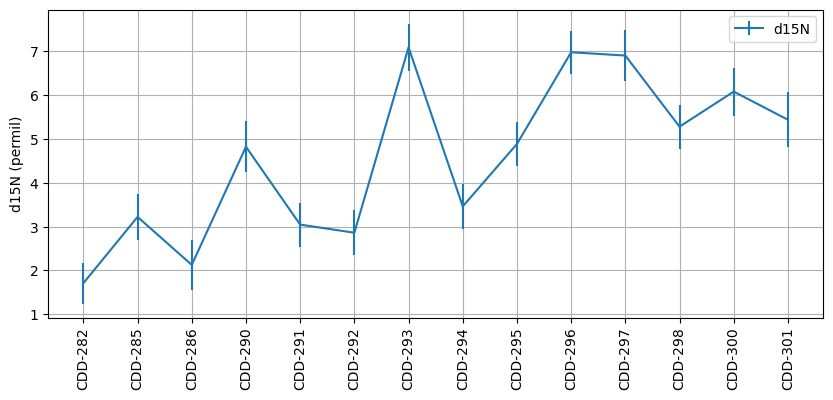

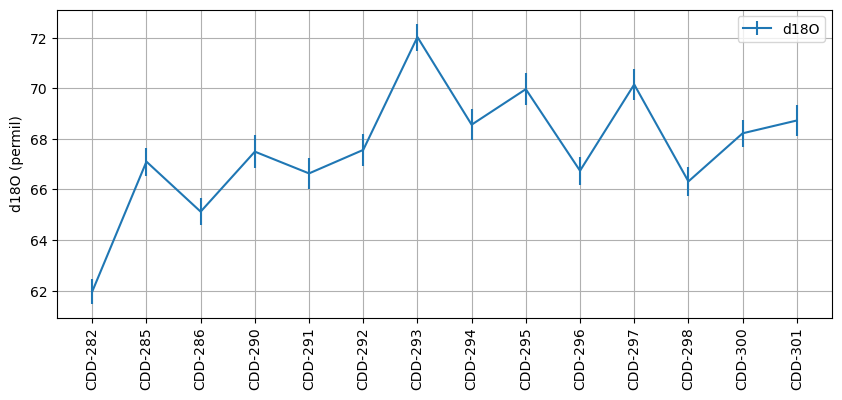

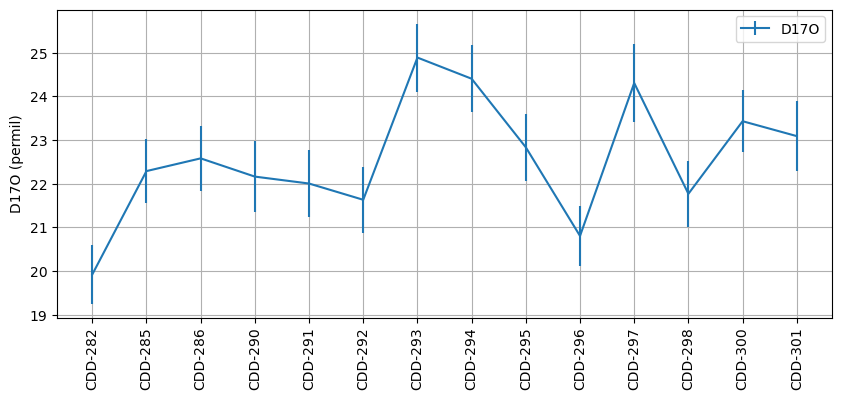

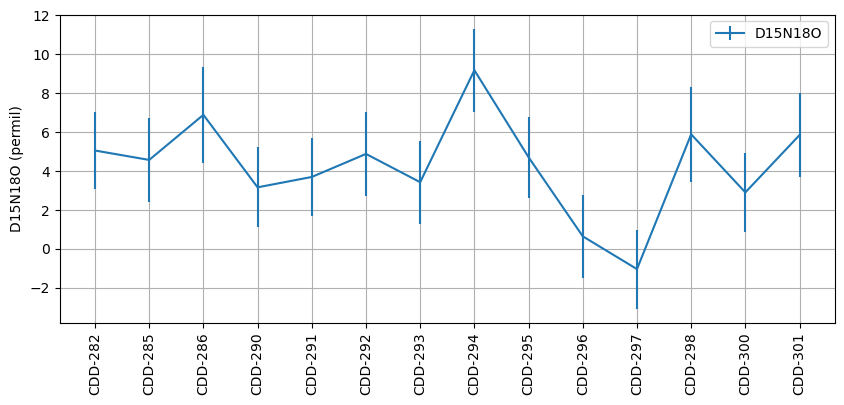

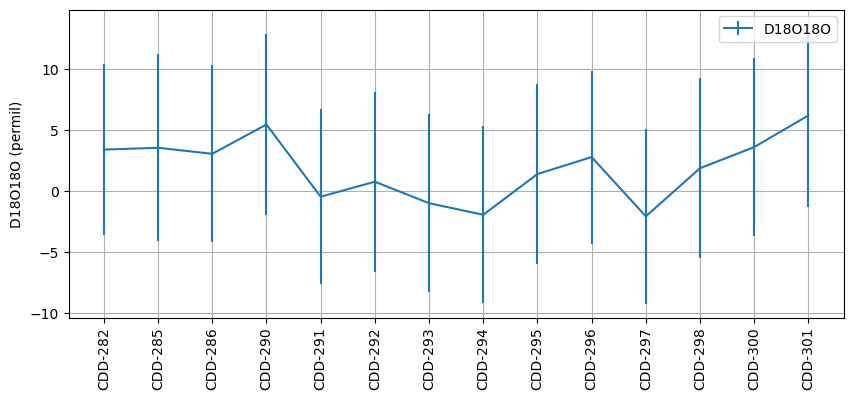

In [53]:
# plots of final summary deltas

# True = plots only samples, False = plots standards also
if True:
    data_plot = data_summary.loc[[row for row in data_summary.index if not row.startswith(('USGS','S1','S2','VS','NICO'))]]
else:
    data_plot = data_summary
    
cols = pd.Series([col for col in data_plot.columns if not col.endswith('_err')]).unique()
    
# plots for each delta
for delta in cols:
    fig,ax=plt.subplots(figsize=[10,4])
    ax.errorbar(x=data_plot.index, y=data_plot[delta]*1e3,
               yerr=data_plot[delta+'_err']*1e3, label=delta)
   
    ax.set_ylabel(delta+' (permil)')
    ax.grid()
    ax.legend()
    ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## Save all steps to excel file

In [54]:
output_file = os.getcwd().split('/')[-1]+'_calibrated_'+data_type+'_'+current_date_string+'.xlsx'

if data_type=='M0+noM0':
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Small deltas M0 calculations':small_deltas,
               'Derived deltas':derived_deltas,
               'Reported deltas':data_summary,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Calibration metadata no-M0': pd.DataFrame(mean_metadata_noM0.items()),
              'Pooled raw errors': pooled_errs,
              'Pooled final errors':pooled_err_final}
else:
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Reported deltas':data_summary,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Pooled raw errors': pooled_errs,
              'Pooled final errors':pooled_err_final}

for sheet_name, df in to_save.items():
    # Check if the file exists
    if not os.path.exists(os.path.join(output_file)):
        # If the file doesn't exist, create a new ExcelWriter object without mode='a'
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('Excel file created:',os.path.join(output_file),'\nNew sheet added to',output_file,':',sheet_name)
    else:
        # If the file exists, create an ExcelWriter object with mode='a' to append to the existing file
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl', mode='a',if_sheet_exists='replace') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('New sheet added to',output_file,':',sheet_name)

Excel file created: CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx 
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Small deltas uncalibrated
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Small deltas calibrated
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Small deltas M0 calculations
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Derived deltas
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Reported deltas
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Calibration metadata M0
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Calibration metadata no-M0
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Pooled raw errors
New sheet added to CDD-282-310_NO3_calibrated_M0+noM0_2025-07-17.xlsx : Pooled final errors
